In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU name: NVIDIA A100-SXM4-40GB


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import time
import copy
import numpy as np
import matplotlib.pyplot as plt
from torch.cuda.amp import autocast, GradScaler

In [3]:
BATCH_SIZE = 128
LEARNING_RATE = 0.001
EPOCHS = 5
NUM_CLASSES = 10
BATCH_SIZES = [32, 64, 128]
PRECISION_MODES = ["fp32", "fp16"]

Preparing CIFAR-10 Dataset

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

In [5]:
train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 170M/170M [00:13<00:00, 13.1MB/s]


In [6]:
def get_dataloaders(batch_size):
    train_loader = torch.utils.data.DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2
    )

    test_loader = torch.utils.data.DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2
    )

    return train_loader, test_loader

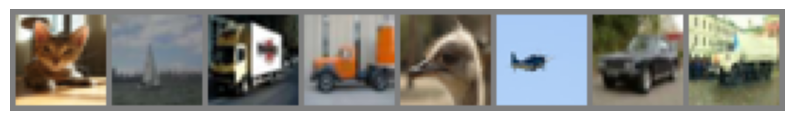

Labels: ['cat', 'ship', 'truck', 'truck', 'bird', 'airplane', 'automobile', 'truck']


In [7]:
classes = train_dataset.classes

def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.figure(figsize=(10, 4))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

train_loader_vis, _ = get_dataloaders(batch_size=32)

dataiter = iter(train_loader_vis)
images, labels = next(dataiter)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images[:8]))
print("Labels:", [classes[label] for label in labels[:8]])

Building CNN Model

In [8]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, NUM_CLASSES)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [9]:
from torchvision.models import resnet18

def get_model(model_name):
    if model_name == "SimpleCNN":
        return SimpleCNN()
    elif model_name == "ResNet18":
        return resnet18(num_classes=10)

In [10]:
def evaluate_model(model, data_loader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy

In [11]:
def measure_inference_latency(model, device, batch_size=128, num_runs=50):
    model.eval()
    dummy_input = torch.randn(batch_size, 3, 32, 32).to(device)

    for _ in range(10):
        _ = model(dummy_input)

    if device.type == 'cuda':
        torch.cuda.synchronize()

    start = time.time()

    with torch.no_grad():
        for _ in range(num_runs):
            _ = model(dummy_input)

    if device.type == 'cuda':
        torch.cuda.synchronize()

    end = time.time()

    return (end - start) / num_runs

In [12]:
def train_model(model_name, device, batch_size, precision="fp32", epochs=EPOCHS):
    print(f"\nModel: {model_name} | Device: {device} | Batch: {batch_size} | Precision: {precision}")

    train_loader, test_loader = get_dataloaders(batch_size)

    model = get_model(model_name).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats()

    if device.type == "cuda" and precision == "fp16":
        scaler = GradScaler()
    else:
        scaler = None

    total_images = len(train_dataset) * epochs
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            if device.type == "cuda" and precision == "fp16":
                with autocast():
                    outputs = model(images)
                    loss = criterion(outputs, labels)

                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            else:
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

            running_loss += loss.item()

    total_time = time.time() - start_time
    accuracy = evaluate_model(model, test_loader, device)
    throughput = total_images / total_time
    latency = measure_inference_latency(model, device, batch_size=batch_size)

    if device.type == "cuda":
        gpu_memory = torch.cuda.max_memory_allocated() / 1024**2
    else:
        gpu_memory = 0

    return {
        "model": model_name,
        "device": str(device),
        "batch_size": batch_size,
        "precision": precision,
        "training_time": total_time,
        "accuracy": accuracy,
        "throughput": throughput,
        "latency": latency,
        "gpu_memory_mb": gpu_memory
    }

Running CPU Benchmark

In [13]:
results = []

models = ["SimpleCNN", "ResNet18"]
devices = ["cpu"]

if torch.cuda.is_available():
    devices.append("cuda")

for model_name in models:
    for batch_size in BATCH_SIZES:
        for device_name in devices:
            for precision in PRECISION_MODES:

                if device_name == "cpu" and precision == "fp16":
                    continue

                device = torch.device(device_name)

                result = train_model(
                    model_name=model_name,
                    device=device,
                    batch_size=batch_size,
                    precision=precision,
                    epochs=EPOCHS
                )

                results.append(result)


Model: SimpleCNN | Device: cpu | Batch: 32 | Precision: fp32

Model: SimpleCNN | Device: cuda | Batch: 32 | Precision: fp32

Model: SimpleCNN | Device: cuda | Batch: 32 | Precision: fp16


/tmp/ipykernel_7720/3516036672.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_7720/3516036672.py:32: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



Model: SimpleCNN | Device: cpu | Batch: 64 | Precision: fp32

Model: SimpleCNN | Device: cuda | Batch: 64 | Precision: fp32

Model: SimpleCNN | Device: cuda | Batch: 64 | Precision: fp16

Model: SimpleCNN | Device: cpu | Batch: 128 | Precision: fp32

Model: SimpleCNN | Device: cuda | Batch: 128 | Precision: fp32

Model: SimpleCNN | Device: cuda | Batch: 128 | Precision: fp16

Model: ResNet18 | Device: cpu | Batch: 32 | Precision: fp32

Model: ResNet18 | Device: cuda | Batch: 32 | Precision: fp32

Model: ResNet18 | Device: cuda | Batch: 32 | Precision: fp16

Model: ResNet18 | Device: cpu | Batch: 64 | Precision: fp32

Model: ResNet18 | Device: cuda | Batch: 64 | Precision: fp32

Model: ResNet18 | Device: cuda | Batch: 64 | Precision: fp16

Model: ResNet18 | Device: cpu | Batch: 128 | Precision: fp32

Model: ResNet18 | Device: cuda | Batch: 128 | Precision: fp32

Model: ResNet18 | Device: cuda | Batch: 128 | Precision: fp16


In [14]:
import pandas as pd

df = pd.DataFrame(results)
print(df)

        model device  batch_size precision  training_time  accuracy  \
0   SimpleCNN    cpu          32      fp32     142.682120     74.93   
1   SimpleCNN   cuda          32      fp32      38.571867     75.09   
2   SimpleCNN   cuda          32      fp16      40.428807     74.94   
3   SimpleCNN    cpu          64      fp32     112.991266     74.04   
4   SimpleCNN   cuda          64      fp32      34.632668     73.23   
5   SimpleCNN   cuda          64      fp16      34.999508     74.12   
6   SimpleCNN    cpu         128      fp32      98.869938     72.23   
7   SimpleCNN   cuda         128      fp32      34.056933     72.98   
8   SimpleCNN   cuda         128      fp16      32.984791     73.31   
9    ResNet18    cpu          32      fp32     624.156074     75.98   
10   ResNet18   cuda          32      fp32      88.027483     75.85   
11   ResNet18   cuda          32      fp16     104.104793     75.52   
12   ResNet18    cpu          64      fp32     411.247023     74.58   
13   R

In [15]:
def calculate_speedup(df):
    speedups = []

    for model in df['model'].unique():
        for batch in df['batch_size'].unique():
            for precision in df['precision'].unique():

                cpu_row = df[
                    (df['model'] == model) &
                    (df['batch_size'] == batch) &
                    (df['device'] == 'cpu') &
                    (df['precision'] == precision)
                ]

                gpu_row = df[
                    (df['model'] == model) &
                    (df['batch_size'] == batch) &
                    (df['device'] == 'cuda') &
                    (df['precision'] == precision)
                ]

                if not cpu_row.empty and not gpu_row.empty:
                    speedup = cpu_row['training_time'].values[0] / gpu_row['training_time'].values[0]

                    speedups.append({
                        "model": model,
                        "batch_size": batch,
                        "precision": precision,
                        "speedup": speedup
                    })

    return pd.DataFrame(speedups)

speedup_df = calculate_speedup(df)
print(speedup_df)

       model  batch_size precision   speedup
0  SimpleCNN          32      fp32  3.699124
1  SimpleCNN          64      fp32  3.262563
2  SimpleCNN         128      fp32  2.903078
3   ResNet18          32      fp32  7.090468
4   ResNet18          64      fp32  8.504594
5   ResNet18         128      fp32  9.328732


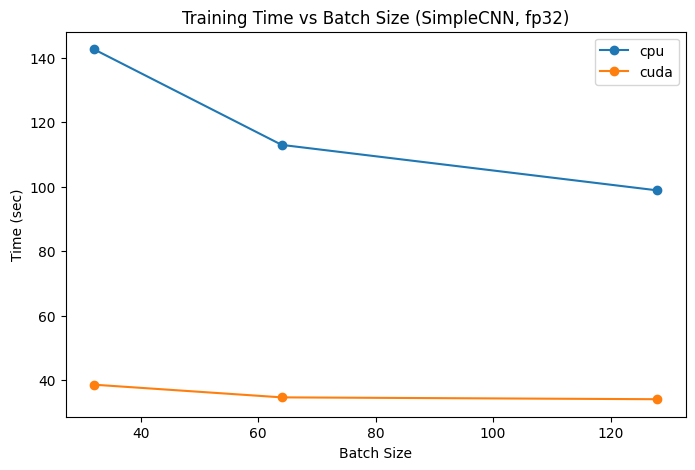

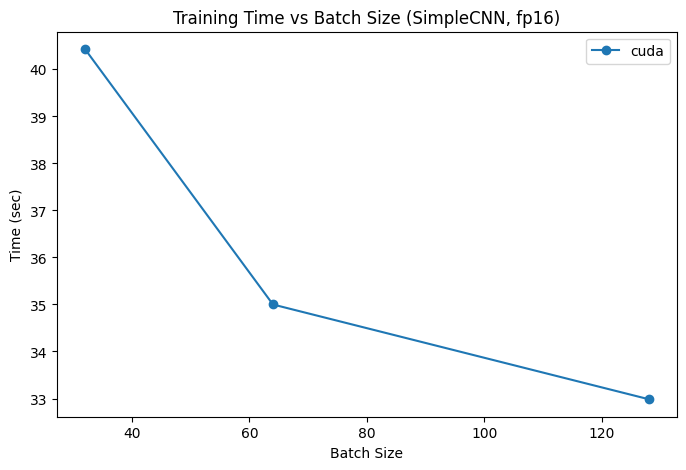

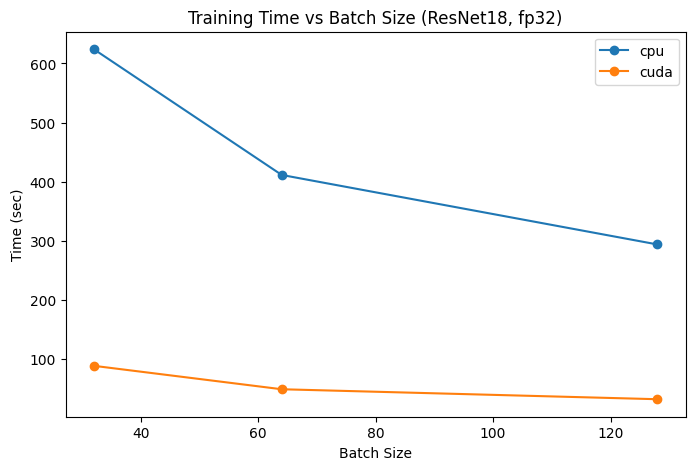

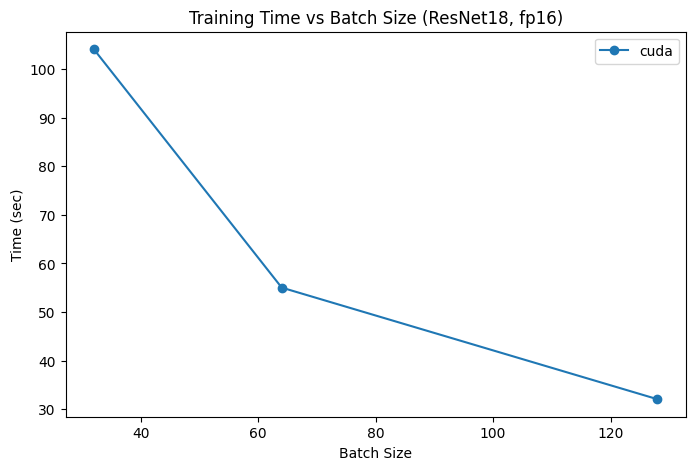

In [16]:
import matplotlib.pyplot as plt

for model in df['model'].unique():
    for precision in df['precision'].unique():
        subset = df[(df['model'] == model) & (df['precision'] == precision)]

        if subset.empty:
            continue

        plt.figure(figsize=(8, 5))

        for device in subset['device'].unique():
            d = subset[subset['device'] == device].sort_values('batch_size')
            plt.plot(d['batch_size'], d['training_time'], marker='o', label=device)

        plt.title(f"Training Time vs Batch Size ({model}, {precision})")
        plt.xlabel("Batch Size")
        plt.ylabel("Time (sec)")
        plt.legend()
        plt.show()

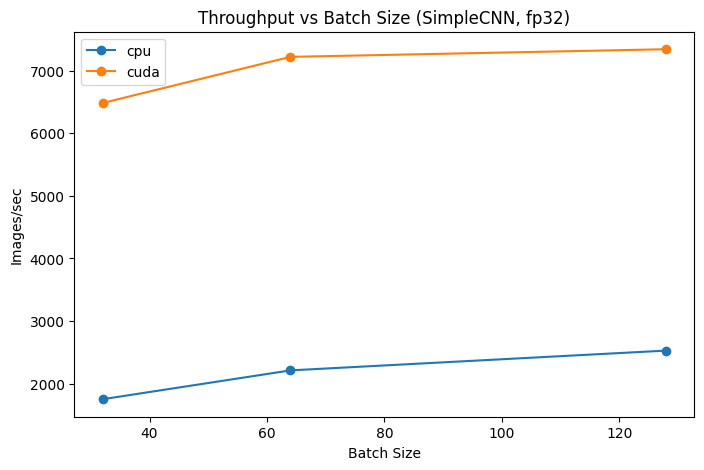

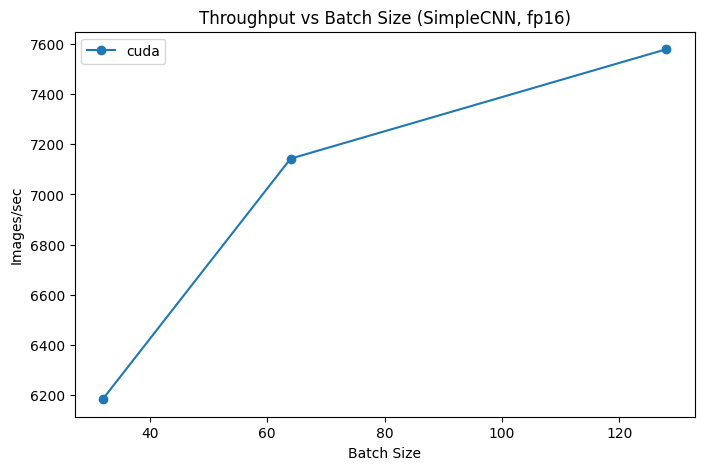

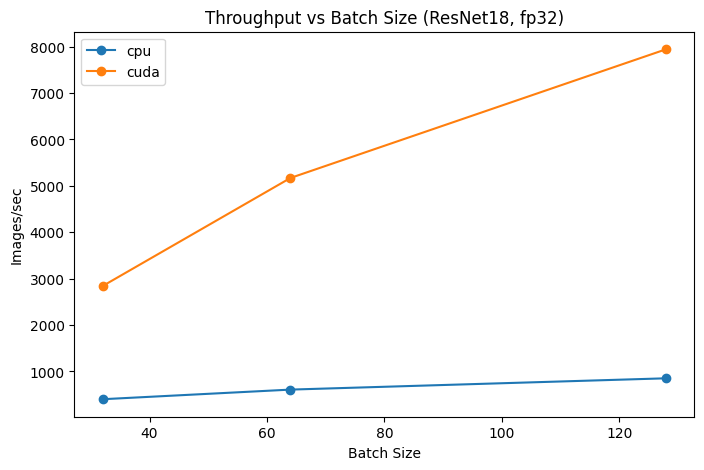

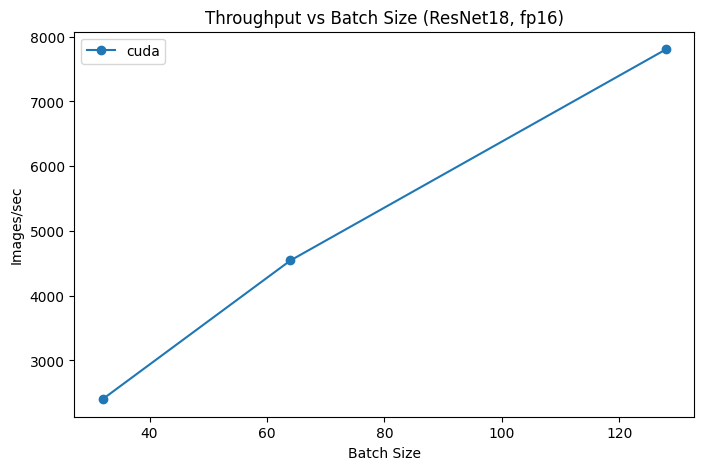

In [17]:
for model in df['model'].unique():
    for precision in df['precision'].unique():
        subset = df[(df['model'] == model) & (df['precision'] == precision)]

        if subset.empty:
            continue

        plt.figure(figsize=(8, 5))

        for device in subset['device'].unique():
            d = subset[subset['device'] == device].sort_values('batch_size')
            plt.plot(d['batch_size'], d['throughput'], marker='o', label=device)

        plt.title(f"Throughput vs Batch Size ({model}, {precision})")
        plt.xlabel("Batch Size")
        plt.ylabel("Images/sec")
        plt.legend()
        plt.show()

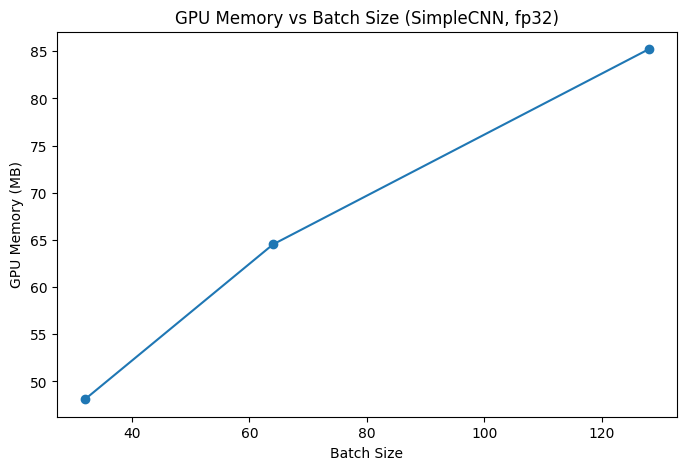

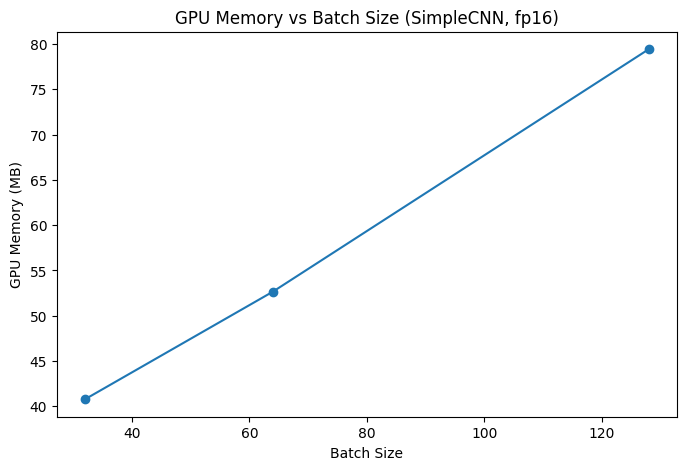

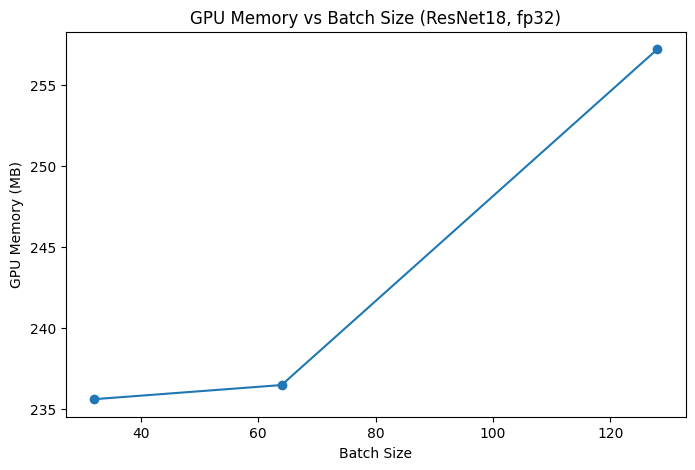

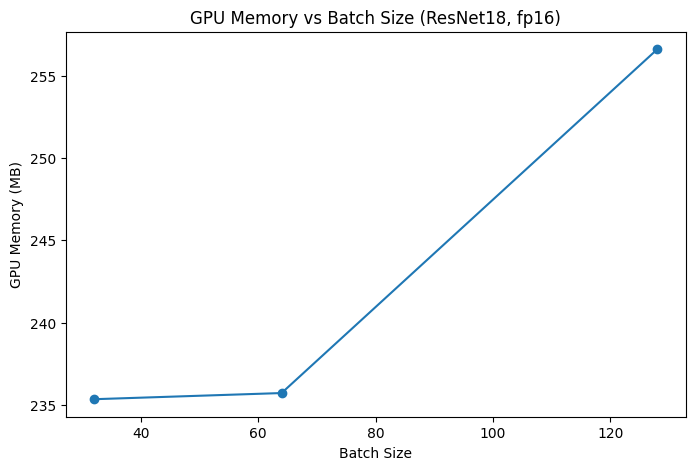

In [18]:
gpu_df = df[df['device'] == 'cuda']

for model in gpu_df['model'].unique():
    for precision in gpu_df['precision'].unique():
        subset = gpu_df[(gpu_df['model'] == model) & (gpu_df['precision'] == precision)]

        if subset.empty:
            continue

        subset = subset.sort_values('batch_size')

        plt.figure(figsize=(8, 5))
        plt.plot(subset['batch_size'], subset['gpu_memory_mb'], marker='o')
        plt.title(f"GPU Memory vs Batch Size ({model}, {precision})")
        plt.xlabel("Batch Size")
        plt.ylabel("GPU Memory (MB)")
        plt.show()

In [19]:
print("\n--- Experiment Summary ---")

cpu_avg_time = df[df['device'] == 'cpu']['training_time'].mean()
gpu_avg_time = df[df['device'] == 'cuda']['training_time'].mean()

cpu_avg_acc = df[df['device'] == 'cpu']['accuracy'].mean()
gpu_avg_acc = df[df['device'] == 'cuda']['accuracy'].mean()

cpu_avg_latency = df[df['device'] == 'cpu']['latency'].mean()
gpu_avg_latency = df[df['device'] == 'cuda']['latency'].mean()

avg_speedup = cpu_avg_time / gpu_avg_time

print(f"Average CPU Training Time: {cpu_avg_time:.2f} sec")
print(f"Average GPU Training Time: {gpu_avg_time:.2f} sec")
print(f"Average CPU Accuracy: {cpu_avg_acc:.2f}%")
print(f"Average GPU Accuracy: {gpu_avg_acc:.2f}%")
print(f"Average CPU Latency: {cpu_avg_latency:.6f} sec")
print(f"Average GPU Latency: {gpu_avg_latency:.6f} sec")
print(f"Average Speedup: {avg_speedup:.2f}x")


--- Experiment Summary ---
Average CPU Training Time: 280.58 sec
Average GPU Training Time: 47.89 sec
Average CPU Accuracy: 73.87%
Average GPU Accuracy: 74.23%
Average CPU Latency: 0.015319 sec
Average GPU Latency: 0.001538 sec
Average Speedup: 5.86x


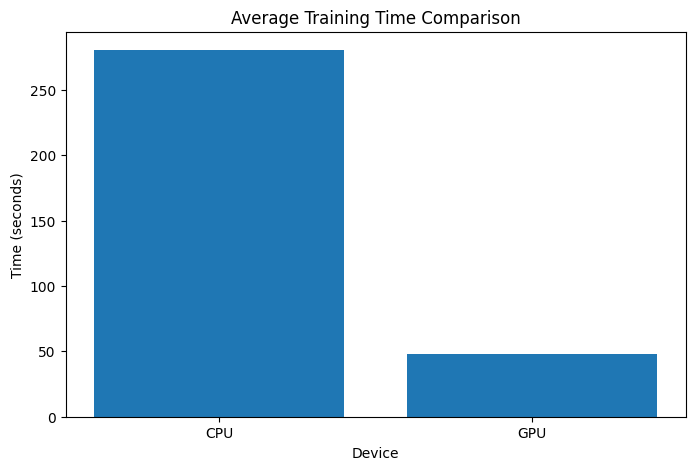

In [20]:
devices = ["CPU", "GPU"]
times = [cpu_avg_time, gpu_avg_time]

plt.figure(figsize=(8, 5))
plt.bar(devices, times)
plt.title("Average Training Time Comparison")
plt.ylabel("Time (seconds)")
plt.xlabel("Device")
plt.show()

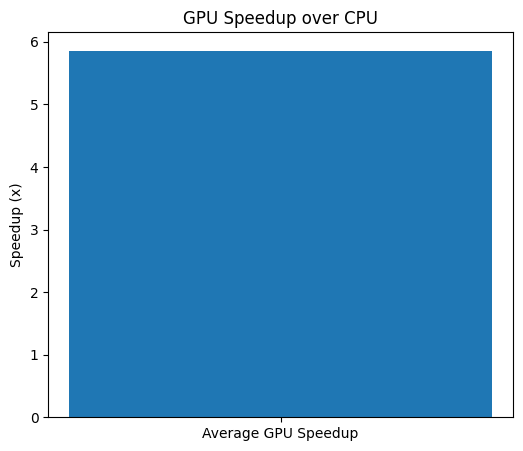

In [21]:
plt.figure(figsize=(6, 5))
plt.bar(["Average GPU Speedup"], [avg_speedup])
plt.title("GPU Speedup over CPU")
plt.ylabel("Speedup (x)")
plt.show()

In [22]:
if torch.cuda.is_available():
    print("Allocated GPU memory:", torch.cuda.memory_allocated(0) / 1024**2, "MB")
    print("Reserved GPU memory:", torch.cuda.memory_reserved(0) / 1024**2, "MB")

Allocated GPU memory: 17.25 MB
Reserved GPU memory: 292.0 MB


In [23]:
summary = {
    "avg_cpu_time": round(cpu_avg_time, 2),
    "avg_gpu_time": round(gpu_avg_time, 2),
    "avg_cpu_accuracy": round(cpu_avg_acc, 2),
    "avg_gpu_accuracy": round(gpu_avg_acc, 2),
    "avg_speedup": round(avg_speedup, 2)
}

print(summary)

{'avg_cpu_time': np.float64(280.58), 'avg_gpu_time': np.float64(47.89), 'avg_cpu_accuracy': np.float64(73.87), 'avg_gpu_accuracy': np.float64(74.23), 'avg_speedup': np.float64(5.86)}


In [24]:
print("Conclusion:")
print(f"Across all valid configurations, GPU training reduced average training time from {cpu_avg_time:.2f}s to {gpu_avg_time:.2f}s.")
print(f"This yielded an average speedup of {avg_speedup:.2f}x while maintaining comparable accuracy.")
print("The benchmark also captured inference latency, GPU memory usage, and the effect of mixed precision on performance.")
print("Overall, the results show that model complexity, batch size, and precision mode all influence how effectively GPU hardware is utilized.")

Conclusion:
Across all valid configurations, GPU training reduced average training time from 280.58s to 47.89s.
This yielded an average speedup of 5.86x while maintaining comparable accuracy.
The benchmark also captured inference latency, GPU memory usage, and the effect of mixed precision on performance.
Overall, the results show that model complexity, batch size, and precision mode all influence how effectively GPU hardware is utilized.


In [25]:
df

,model,device,batch_size,precision,training_time,accuracy,throughput,latency,gpu_memory_mb
0,SimpleCNN,cpu,32,fp32,142.682120,74.93,1752.146662,0.007219,0.000000
1,SimpleCNN,cuda,32,fp32,38.571867,75.09,6481.407811,0.000468,48.117676
2,SimpleCNN,cuda,32,fp16,40.428807,74.94,6183.709585,0.000465,40.785645
3,SimpleCNN,cpu,64,fp32,112.991266,74.04,2212.560403,0.008319,0.000000
4,SimpleCNN,cuda,64,fp32,34.632668,73.23,7218.617879,0.000492,64.524902
5,SimpleCNN,cuda,64,fp16,34.999508,74.12,7142.957621,0.000480,52.660645
6,SimpleCNN,cpu,128,fp32,98.869938,72.23,2528.574456,0.016031,0.000000
7,SimpleCNN,cuda,128,fp32,34.056933,72.98,7340.649172,0.000487,85.215332
8,SimpleCNN,cuda,128,fp16,32.984791,73.31,7579.250682,0.000485,79.412598
9,ResNet18,cpu,32,fp32,624.156074,75.98,400.540843,0.012768,0.000000


In [26]:
df.to_csv("benchmark_results.csv", index=False)